In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [2]:
param_name = 'chargeSpeed'
expt_type = 'playfight/without_cover_story/sentiment_analyses/'
rootfile_loc = f'../../data/text_responses/{expt_type}'

df = pd.read_csv(f'{rootfile_loc}/data_with_sentiment_scores.csv', index_col=[0])
df = df.reset_index()
df

,index,subID,stimset_rows,chargeSpeed,stim_dur,responses,movie,trial_num,neg_score,neu_score,pos_score,pos-neg,pos-neu,neg-neu,neu-neg
0,5,28024,65,1.5,7962,now they slowly met and touched twice,1b1159fc-de2b-4ae5-a736-d98d8524a366,5,0.003994,0.731555,0.264451,0.260457,-0.467103,-0.727561,0.727561
1,3,28022,59,1.5,8002,The dots meet each other warmly.,1a8cf3c1-690b-449c-bb36-fd3b251837c1,3,0.004204,0.169153,0.826644,0.822440,0.657491,-0.164949,0.164949
2,3,28083,46,1.5,8083,both meeting each other,50919f52-6a9c-4824-b24f-2f1aebd58e1b,3,0.005532,0.861102,0.133366,0.127834,-0.727736,-0.855570,0.855570
3,1,28050,98,1.5,8648,slowly came together,8ed7c0fc-1490-4e35-a000-7f7357a0772a,1,0.006125,0.355109,0.638766,0.632641,0.283657,-0.348984,0.348984
4,1,28070,26,1.5,8284,The dots moved to the left and down and collid...,29e7c94f-a6bf-4f1d-8ea1-46efbdb6a836,1,0.006636,0.873458,0.119906,0.113270,-0.753552,-0.866822,0.866822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,4,28056,4,9.0,8167,The white dot attacked the black dot.,abb20336-74c4-448b-a5f7-252c765a55f4,4,0.482806,0.497981,0.019213,-0.463593,-0.478769,-0.015176,0.015176
717,6,28022,59,9.0,8031,The dots looked like enemy of each other and f...,5b2465b2-47b6-4cc7-b06f-c362ff7454f8,6,0.493080,0.482383,0.024537,-0.468543,-0.457846,0.010698,-0.010698
718,5,28058,13,9.0,9886,the two dots seem to be fighting,6a57f963-5846-4eaa-a5d2-0e658499a4a9,5,0.500883,0.477192,0.021925,-0.478958,-0.455267,0.023691,-0.023691
719,3,28085,51,9.0,8101,Hitting each other,9301277e-6b35-4aa7-bd52-4f56ae0f029b,3,0.543805,0.415098,0.041097,-0.502707,-0.374001,0.128706,-0.128706


In [3]:
import matplotlib.pyplot as plt
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [4]:
param_name = 'chargeSpeed'

In [5]:
results_dir = '../../results/text_analysis/pf/no_cover_story/'

In [6]:
colors_plot = 'tab:red'

In [7]:
# pip install nltk


In [8]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/f0053cz/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [9]:
# Load NRC VAD (CSV format: word,valence,arousal,dominance)
vad = pd.read_csv("./NRC-VAD-Lexicon-v2.1/NRC-VAD-Lexicon-v2.1.txt", sep="\t")
vad_dict = dict(zip(vad['term'], vad['arousal']))
vad_dict_valence = dict(zip(vad['term'], vad['valence']))

# def compute_arousal(text):
#     tokens = word_tokenize(text.lower())
#     scores = [vad_dict[word] for word in tokens if word in vad_dict]
#     return sum(scores) / len(scores) if scores else None

import re

def compute_arousal(text):
    tokens = re.findall(r'\b\w+\b', text.lower())
    print(tokens)
    scores = [vad_dict[word] for word in tokens if word in vad_dict]
    print(scores)
    return sum(scores) / len(scores) if scores else None


def compute_valence(text):
    tokens = re.findall(r'\b\w+\b', text.lower())
    print(tokens)
    scores = [vad_dict_valence[word] for word in tokens if word in vad_dict_valence]
    print(scores)
    return sum(scores) / len(scores) if scores else None


In [10]:
vad.sort_values(by='arousal', ascending=False).head(10)

,term,valence,arousal,dominance
16695,explosively,-0.111,1.0,0.815
2277,ardently,1.000,1.0,0.296
29718,maul,-0.667,1.0,0.704
2330,armageddon,-1.000,1.0,0.833
49950,turbocharger,0.667,1.0,0.778
36721,popeyed,-0.333,1.0,0.000
45444,stabber,-1.000,1.0,0.905
45445,stabbing,-0.810,1.0,-0.370
49350,traindriver,0.000,1.0,0.625
49951,turbojet,0.278,1.0,0.963


In [11]:
vad.sort_values(by='arousal', ascending=True).head(10)

,term,valence,arousal,dominance
25683,insubstantiality,-0.619,-1.0,-0.926
23901,ignorable,-0.333,-1.0,-0.810
23871,idly,0.000,-1.0,-0.519
51065,unfrequented,-0.333,-1.0,-0.476
37177,predestination,0.000,-1.0,-0.167
23797,iciness,-0.389,-1.0,-0.125
51079,unfussy,0.583,-1.0,0.222
23781,icecap,0.222,-1.0,0.095
23778,icebound,-0.458,-1.0,-0.333
23745,hypothyroidism,-0.750,-1.0,-0.519


In [12]:
nltk.download('punkt', download_dir='/tmp/nltk_data')
import os
nltk.data.path.append('/tmp/nltk_data')


[nltk_data] Downloading package punkt to /tmp/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [13]:
text = "activated"
arousal_score = compute_arousal(text)
print(arousal_score)

['activated']
[1.0]
1.0


In [14]:
text = "abominableness"
arousal_score = compute_arousal(text)
print(arousal_score)

['abominableness']
[-0.667]
-0.667


In [15]:
text = "peaceful place"
arousal_score = compute_arousal(text)
print(arousal_score)

['peaceful', 'place']
[-0.892, -0.478]
-0.685


In [16]:
text = "very exciting"
arousal_score = compute_arousal(text)
print(arousal_score)

['very', 'exciting']
[0.0, 0.584]
0.292


In [17]:
text = "horrible explosion"
arousal_score = compute_arousal(text)
print(arousal_score)

['horrible', 'explosion']
[0.714, 0.96]
0.837


In [18]:
text = "The explosion was terrifying and loud."
arousal_score = compute_arousal(text)
print(arousal_score)


['the', 'explosion', 'was', 'terrifying', 'and', 'loud']
[0.96, -0.083, 0.672, 0.0, 0.3]
0.3698


# without cover story

In [19]:
df['arousal_score'] = df['responses'].apply(compute_arousal)
df

['now', 'they', 'slowly', 'met', 'and', 'touched', 'twice']
[-0.164, 0.0, -0.63, -0.276, 0.0, -0.24, -0.084]
['the', 'dots', 'meet', 'each', 'other', 'warmly']
[0.02, 0.0, -0.54, -0.667]
['both', 'meeting', 'each', 'other']
[-0.206, 0.138, 0.0, -0.54]
['slowly', 'came', 'together']
[-0.63, 0.016, -0.216]
['the', 'dots', 'moved', 'to', 'the', 'left', 'and', 'down', 'and', 'collided', 'gently', 'twice']
[0.519, 0.0, -0.26, 0.0, -0.34, 0.0, -0.49, -0.084]
['slowly', 'came', 'together', 'twice']
[-0.63, 0.016, -0.216, -0.084]
['the', 'dots', 'seemed', 'to', 'move', 'more', 'gently', 'this', 'time', 'and', 'almost', 'met', 'each', 'other', 'gently', 'twice', 'instead', 'of', 'colliding', 'with', 'each', 'other', 'this', 'time']
[0.0, 0.294, 0.0, -0.49, 0.0, -0.424, 0.0, -0.258, -0.276, 0.0, -0.54, -0.49, -0.084, -0.192, 0.0, 0.0, 0.0, -0.54, 0.0, -0.424]
['they', 'are', 'exchanging', 'greetings']
[0.0, 0.0]
['the', 'dots', 'approached', 'each', 'other', 'cautiously', 'and', 'interacted', 'a

,index,subID,stimset_rows,chargeSpeed,stim_dur,responses,movie,trial_num,neg_score,neu_score,pos_score,pos-neg,pos-neu,neg-neu,neu-neg,arousal_score
0,5,28024,65,1.5,7962,now they slowly met and touched twice,1b1159fc-de2b-4ae5-a736-d98d8524a366,5,0.003994,0.731555,0.264451,0.260457,-0.467103,-0.727561,0.727561,-0.199143
1,3,28022,59,1.5,8002,The dots meet each other warmly.,1a8cf3c1-690b-449c-bb36-fd3b251837c1,3,0.004204,0.169153,0.826644,0.822440,0.657491,-0.164949,0.164949,-0.296750
2,3,28083,46,1.5,8083,both meeting each other,50919f52-6a9c-4824-b24f-2f1aebd58e1b,3,0.005532,0.861102,0.133366,0.127834,-0.727736,-0.855570,0.855570,-0.152000
3,1,28050,98,1.5,8648,slowly came together,8ed7c0fc-1490-4e35-a000-7f7357a0772a,1,0.006125,0.355109,0.638766,0.632641,0.283657,-0.348984,0.348984,-0.276667
4,1,28070,26,1.5,8284,The dots moved to the left and down and collid...,29e7c94f-a6bf-4f1d-8ea1-46efbdb6a836,1,0.006636,0.873458,0.119906,0.113270,-0.753552,-0.866822,0.866822,-0.081875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,4,28056,4,9.0,8167,The white dot attacked the black dot.,abb20336-74c4-448b-a5f7-252c765a55f4,4,0.482806,0.497981,0.019213,-0.463593,-0.478769,-0.015176,0.015176,-0.420000
717,6,28022,59,9.0,8031,The dots looked like enemy of each other and f...,5b2465b2-47b6-4cc7-b06f-c362ff7454f8,6,0.493080,0.482383,0.024537,-0.468543,-0.457846,0.010698,-0.010698,0.074857
718,5,28058,13,9.0,9886,the two dots seem to be fighting,6a57f963-5846-4eaa-a5d2-0e658499a4a9,5,0.500883,0.477192,0.021925,-0.478958,-0.455267,0.023691,-0.023691,-0.149200
719,3,28085,51,9.0,8101,Hitting each other,9301277e-6b35-4aa7-bd52-4f56ae0f029b,3,0.543805,0.415098,0.041097,-0.502707,-0.374001,0.128706,-0.128706,0.153333


In [20]:
df['valence_score_again'] = df['responses'].apply(compute_valence)
df

['now', 'they', 'slowly', 'met', 'and', 'touched', 'twice']
[0.226, 0.0, -0.146, 0.358, 0.0, 0.184, 0.234]
['the', 'dots', 'meet', 'each', 'other', 'warmly']
[0.52, 0.125, -0.056, 0.952]
['both', 'meeting', 'each', 'other']
[0.036, 0.5, 0.125, -0.056]
['slowly', 'came', 'together']
[-0.146, 0.166, 0.748]
['the', 'dots', 'moved', 'to', 'the', 'left', 'and', 'down', 'and', 'collided', 'gently', 'twice']
[0.524, 0.0, -0.292, 0.0, -0.584, 0.0, 0.834, 0.234]
['slowly', 'came', 'together', 'twice']
[-0.146, 0.166, 0.748, 0.234]
['the', 'dots', 'seemed', 'to', 'move', 'more', 'gently', 'this', 'time', 'and', 'almost', 'met', 'each', 'other', 'gently', 'twice', 'instead', 'of', 'colliding', 'with', 'each', 'other', 'this', 'time']
[0.0, 0.312, 0.667, 0.834, 0.0, 0.208, 0.0, -0.072, 0.358, 0.125, -0.056, 0.834, 0.234, -0.068, 0.0, 0.0, 0.125, -0.056, 0.0, 0.208]
['they', 'are', 'exchanging', 'greetings']
[0.0, 0.0]
['the', 'dots', 'approached', 'each', 'other', 'cautiously', 'and', 'interacted'

,index,subID,stimset_rows,chargeSpeed,stim_dur,responses,movie,trial_num,neg_score,neu_score,pos_score,pos-neg,pos-neu,neg-neu,neu-neg,arousal_score,valence_score_again
0,5,28024,65,1.5,7962,now they slowly met and touched twice,1b1159fc-de2b-4ae5-a736-d98d8524a366,5,0.003994,0.731555,0.264451,0.260457,-0.467103,-0.727561,0.727561,-0.199143,0.122286
1,3,28022,59,1.5,8002,The dots meet each other warmly.,1a8cf3c1-690b-449c-bb36-fd3b251837c1,3,0.004204,0.169153,0.826644,0.822440,0.657491,-0.164949,0.164949,-0.296750,0.385250
2,3,28083,46,1.5,8083,both meeting each other,50919f52-6a9c-4824-b24f-2f1aebd58e1b,3,0.005532,0.861102,0.133366,0.127834,-0.727736,-0.855570,0.855570,-0.152000,0.151250
3,1,28050,98,1.5,8648,slowly came together,8ed7c0fc-1490-4e35-a000-7f7357a0772a,1,0.006125,0.355109,0.638766,0.632641,0.283657,-0.348984,0.348984,-0.276667,0.256000
4,1,28070,26,1.5,8284,The dots moved to the left and down and collid...,29e7c94f-a6bf-4f1d-8ea1-46efbdb6a836,1,0.006636,0.873458,0.119906,0.113270,-0.753552,-0.866822,0.866822,-0.081875,0.089500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,4,28056,4,9.0,8167,The white dot attacked the black dot.,abb20336-74c4-448b-a5f7-252c765a55f4,4,0.482806,0.497981,0.019213,-0.463593,-0.478769,-0.015176,0.015176,-0.420000,-0.132000
717,6,28022,59,9.0,8031,The dots looked like enemy of each other and f...,5b2465b2-47b6-4cc7-b06f-c362ff7454f8,6,0.493080,0.482383,0.024537,-0.468543,-0.457846,0.010698,-0.010698,0.074857,-0.091286
718,5,28058,13,9.0,9886,the two dots seem to be fighting,6a57f963-5846-4eaa-a5d2-0e658499a4a9,5,0.500883,0.477192,0.021925,-0.478958,-0.455267,0.023691,-0.023691,-0.149200,-0.018800
719,3,28085,51,9.0,8101,Hitting each other,9301277e-6b35-4aa7-bd52-4f56ae0f029b,3,0.543805,0.415098,0.041097,-0.502707,-0.374001,0.128706,-0.128706,0.153333,0.007000


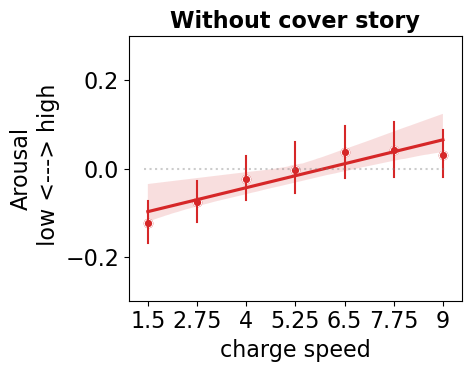

In [23]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(5,4), sharey=False,sharex=True)
sns.lineplot(data=df.reset_index(),x = param_name,y = 'arousal_score', ax=ax,marker = 'o', ls = 'None', color = colors_plot, err_style='bars')
sns.regplot(data = df[['arousal_score', param_name]].groupby([param_name]).mean().reset_index(),x = param_name, y='arousal_score',  ax=ax,marker = 'o', color=colors_plot)#,legend=False)
ax.set_title('Without cover story', fontweight = 'bold')
ax.set_ylabel('Arousal\n low <---> high')
ax.set_xlabel('charge speed')
ax.set_ylim(-.3,.3)
ax.hlines(0,1.4,9.1,color = 'grey',ls=':',alpha = .4)
ax.set_xticks(np.arange(1.5,9.1,1.25),['1.5','2.75','4','5.25','6.5','7.75','9'])
# ax.invert_xaxis()

plt.tight_layout()
plt.savefig(f'{results_dir}/arousal_analysis_withoutcoverstory.png',dpi=300,bbox_inches ='tight')

In [22]:
results_dir

'../../results/text_analysis/pf/no_cover_story/'

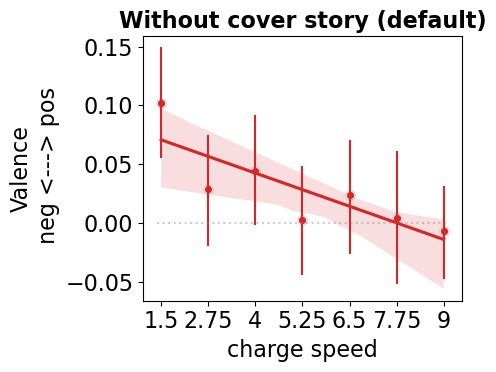

In [23]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(5,4), sharey=False,sharex=True)
sns.lineplot(data=df.reset_index(),x = param_name,y = 'valence_score_again', ax=ax,marker = 'o', ls = 'None', color = colors_plot, err_style='bars')
sns.regplot(data = df[['valence_score_again', param_name]].groupby([param_name]).mean().reset_index(),x = param_name, y='valence_score_again',  ax=ax,marker = 'o', color=colors_plot)#,legend=False)
ax.set_title('Without cover story (default)', fontweight = 'bold')
ax.set_ylabel('Valence\n neg <---> pos')
ax.set_xlabel('charge speed')
# ax.set_ylim(-.2,.2)
ax.hlines(0,1.4,9.1,color = 'grey',ls=':',alpha = .4)
ax.set_xticks(np.arange(1.5,9.1,1.25),['1.5','2.75','4','5.25','6.5','7.75','9'])
# ax.invert_xaxis()

plt.tight_layout()
plt.savefig(f'{results_dir}/valence_analysis_again_withoutcoverstory.png',dpi=300,bbox_inches ='tight')

In [24]:
df = df.dropna(subset=['arousal_score','pos-neg'])
stats.pearsonr(df['arousal_score'], df['pos-neg'])

PearsonRResult(statistic=np.float64(-0.07527693997307978), pvalue=np.float64(0.050423385904140056))

In [25]:
# df = df.dropna(subset=['arousal_score','pos-neg'])
stats.pearsonr(df['arousal_score'], df['pos-neg'])

PearsonRResult(statistic=np.float64(-0.07527693997307978), pvalue=np.float64(0.050423385904140056))

In [26]:
stats.spearmanr(df['arousal_score'], df['pos-neg'], nan_policy='omit')

SignificanceResult(statistic=np.float64(-0.14676951838478286), pvalue=np.float64(0.00012829796294510043))

In [27]:
df['chargeSpeed'] = df['chargeSpeed'] - 1.5
df['chargeSpeed'] = df['chargeSpeed']/7.5
df

/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_56060/2900999163.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['chargeSpeed'] = df['chargeSpeed'] - 1.5
/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_56060/2900999163.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['chargeSpeed'] = df['chargeSpeed']/7.5


,index,subID,stimset_rows,chargeSpeed,stim_dur,responses,movie,trial_num,neg_score,neu_score,pos_score,pos-neg,pos-neu,neg-neu,neu-neg,arousal_score,valence_score_again
0,5,28024,65,0.0,7962,now they slowly met and touched twice,1b1159fc-de2b-4ae5-a736-d98d8524a366,5,0.003994,0.731555,0.264451,0.260457,-0.467103,-0.727561,0.727561,-0.199143,0.122286
1,3,28022,59,0.0,8002,The dots meet each other warmly.,1a8cf3c1-690b-449c-bb36-fd3b251837c1,3,0.004204,0.169153,0.826644,0.822440,0.657491,-0.164949,0.164949,-0.296750,0.385250
2,3,28083,46,0.0,8083,both meeting each other,50919f52-6a9c-4824-b24f-2f1aebd58e1b,3,0.005532,0.861102,0.133366,0.127834,-0.727736,-0.855570,0.855570,-0.152000,0.151250
3,1,28050,98,0.0,8648,slowly came together,8ed7c0fc-1490-4e35-a000-7f7357a0772a,1,0.006125,0.355109,0.638766,0.632641,0.283657,-0.348984,0.348984,-0.276667,0.256000
4,1,28070,26,0.0,8284,The dots moved to the left and down and collid...,29e7c94f-a6bf-4f1d-8ea1-46efbdb6a836,1,0.006636,0.873458,0.119906,0.113270,-0.753552,-0.866822,0.866822,-0.081875,0.089500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,4,28056,4,1.0,8167,The white dot attacked the black dot.,abb20336-74c4-448b-a5f7-252c765a55f4,4,0.482806,0.497981,0.019213,-0.463593,-0.478769,-0.015176,0.015176,-0.420000,-0.132000
717,6,28022,59,1.0,8031,The dots looked like enemy of each other and f...,5b2465b2-47b6-4cc7-b06f-c362ff7454f8,6,0.493080,0.482383,0.024537,-0.468543,-0.457846,0.010698,-0.010698,0.074857,-0.091286
718,5,28058,13,1.0,9886,the two dots seem to be fighting,6a57f963-5846-4eaa-a5d2-0e658499a4a9,5,0.500883,0.477192,0.021925,-0.478958,-0.455267,0.023691,-0.023691,-0.149200,-0.018800
719,3,28085,51,1.0,8101,Hitting each other,9301277e-6b35-4aa7-bd52-4f56ae0f029b,3,0.543805,0.415098,0.041097,-0.502707,-0.374001,0.128706,-0.128706,0.153333,0.007000


In [28]:
df.rename(columns = {'pos-neg':'pos_neg','pos-neu':'pos_neu','neg-neu':'neg_neu','neu-neg':'neu_neg'},inplace=True)

/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_56060/3176042202.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns = {'pos-neg':'pos_neg','pos-neu':'pos_neu','neg-neu':'neg_neu','neu-neg':'neu_neg'},inplace=True)


## Stats

In [29]:
from pymer4.models import Lmer
from pymer4.stats import vif

In [30]:
model = Lmer('arousal_score ~ chargeSpeed +  (1|subID) + (1|movie)', data=df) # ff: anglesm rfx: subject ID
model.fit()

Linear mixed model fit by REML [’lmerMod’]
Formula: arousal_score~chargeSpeed+(1|subID)+(1|movie)

Family: gaussian	 Inference: parametric

Number of observations: 676	 Groups: {'movie': 140.0, 'subID': 103.0}

Log-likelihood: -47.420 	 AIC: 104.839

Random effects:

                 Name    Var    Std
movie     (Intercept)  0.002  0.043
subID     (Intercept)  0.019  0.138
Residual               0.054  0.232

No random effect correlations specified

Fixed effects:



/Users/f0053cz/miniconda3/envs/pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),-0.091,-0.135,-0.048,0.022,147.233,-4.110,0.0,***
chargeSpeed,0.161,0.104,0.218,0.029,110.683,5.539,0.0,***


In [33]:
model = Lmer('arousal_score ~ chargeSpeed + pos_neg + (1|subID) + (1|movie)', data=df) # ff: anglesm rfx: subject ID
model.fit()

Linear mixed model fit by REML [’lmerMod’]
Formula: arousal_score~chargeSpeed+pos_neg+(1|subID)+(1|movie)

Family: gaussian	 Inference: parametric

Number of observations: 676	 Groups: {'movie': 140.0, 'subID': 103.0}

Log-likelihood: -48.926 	 AIC: 109.852

Random effects:

                 Name    Var    Std
movie     (Intercept)  0.002  0.042
subID     (Intercept)  0.019  0.139
Residual               0.054  0.232

No random effect correlations specified

Fixed effects:



/Users/f0053cz/miniconda3/envs/pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),-0.088,-0.132,-0.044,0.022,151.435,-3.946,0.000,***
chargeSpeed,0.154,0.095,0.212,0.030,122.417,5.157,0.000,***
pos_neg,-0.054,-0.154,0.047,0.051,651.763,-1.044,0.297,


In [ ]:
model = Lmer('pos_neg ~ chargeSpeed + arousal_score + (1|subID) + (1|movie)', data=df) # ff: anglesm rfx: subject ID
model.fit()

**NOTE**: Column for 'residuals' not created in model.data, but saved in model.resid only. This is because you have rows with NaNs in your data.

**NOTE** Column for 'fits' not created in model.data, but saved in model.fits only. This is because you have rows with NaNs in your data.

Linear mixed model fit by REML [’lmerMod’]
Formula: pos_neg~chargeSpeed+arousal_score+(1|subID)+(1|movie)

Family: gaussian	 Inference: parametric

Number of observations: 721	 Groups: {'movie': 140.0, 'subID': 103.0}

Log-likelihood: 149.107 	 AIC: -286.215

Random effects:

                 Name    Var    Std
movie     (Intercept)  0.000  0.017
subID     (Intercept)  0.005  0.070
Residual               0.033  0.182

No random effect correlations specified

Fixed effects:



/Users/f0053cz/miniconda3/envs/pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.052,0.023,0.081,0.015,153.487,3.498,0.001,***
chargeSpeed,-0.129,-0.172,-0.086,0.022,114.662,-5.905,0.000,***
arousal_score,-0.028,-0.083,0.028,0.028,652.127,-0.972,0.331,
